In this implementation, I have trained the configuration of UNet+VGG16 with the ideal parameters that I have found through my previous bayesian optimization searches.  I have incorporated the entire dataset into this training and the resulting model has yeilded vastly superior results to previous iterations after only 50 epochs of training.  

In order to train on the entire dataset, the main consideration that I needed to make was that I was operating in an environment with sufficient RAM and a strong enough GPU to ensure that training times were both manageable and reasonable. To do so, I have utilized Google Colab's paid subscription in order to access a 'High-RAM' environment in addition to an L4 GPU for training.  I decided to use the L4, although it is typically reserved for inference, because it provided a reasonable tradeoff between credit expenses (roughly 5 credits/hour) and performance speeds.

The end result of this training is a semantic segmentation model with an roc-auc score of 0.97, capable of detecting the presence of buildings in medium resolution 10m^2/pixel Sentinel 2 satellite imagery.



In [1]:
# Check for GPU availability
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Imports
import os
import numpy as np
import tifffile as tiff
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

!pip install optuna
import optuna

# MODEL SETTINGS
model_name = 'unet_vgg_14'  # Name of the model
percentage_to_load = 100 / 100.0  # Set the % of dataset to be loaded here.
threshold = 0.75  # Set the threshold for metrics here
print(f'\nSETTINGS:')
print(f'Model Name: {model_name}')
print(f'Percentage to Load: {percentage_to_load*100}%')
print(f'Threshold: {threshold}')
print()

# Mount Google Drive
from google.colab import drive
drive.mount('/gdrive')

Num GPUs Available:  1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.0/233.0 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.3 MB/s eta 0:00:00

SETTINGS:
Model Name: unet_vgg_14
Percentage to Load: 100.0%
Threshold: 0.75

Mounted at /gdrive


In [2]:
# Function to count files
def count_files(directory, extension=".tif"):
    return sum(1 for file in os.listdir(directory) if file.endswith(extension))

# Paths to your image and mask directories
image_directory = '/gdrive/My Drive/Dataset/patches/train/images/'
mask_directory = '/gdrive/My Drive/Dataset/patches/train/masks/'

# Counting the TIFF files in both directories
image_count = count_files(image_directory)
mask_count = count_files(mask_directory)

print(f"Number of image files: {image_count}")
print(f"Number of mask files: {mask_count}")

# Load the images and masks into the lists below
images = []
masks = []

# Sort filenames to ensure matching pairs align
image_files = sorted([f for f in os.listdir(image_directory) if f.endswith(".tif")])
mask_files = sorted([f for f in os.listdir(mask_directory) if f.endswith(".tif")])

# Determine how many files to load based on percentage
number_of_files_to_load = int(len(image_files) * percentage_to_load)

# Create a mapping of image names to their corresponding mask names by removing '_Buildings'
image_to_mask = {f: f.replace("_patch", "_Buildings_patch") for f in image_files}

# Only iterate over the subset of files determined by the percentage
print(f'Attempting to load {percentage_to_load*100}% of dataset: {number_of_files_to_load} images/mask pairs...')
for count, image_name in enumerate(tqdm(image_files[:number_of_files_to_load]), start=1):
    try:
        img_path = os.path.join(image_directory, image_name)
        mask_name = image_to_mask[image_name]
        mask_path = os.path.join(mask_directory, mask_name)

        if os.path.exists(mask_path):
            img = tiff.imread(img_path)
            mask = tiff.imread(mask_path)

            images.append(img)
            masks.append(mask)
        else:
            print(f'\nMask not found for image: {image_name}')
    except Exception as e:
        print(f'\nError loading image/mask pair {image_name}: {e}')

print("\nLoading complete.")

# Check if the number of images and masks loaded are equal
if len(images) != len(masks):
    raise ValueError("The number of loaded images and masks do not match!")

Number of image files: 4787
Number of mask files: 4787
Attempting to load 100.0% of dataset: 4787 images/mask pairs...


100%|██████████| 4787/4787 [33:13<00:00,  2.40it/s]


Loading complete.


In [3]:
# Convert the lists to numpy arrays
images = np.array(images, dtype=np.float32)
masks = np.array(masks, dtype=np.float32)

# Normalize the values
images /= 255.0
masks /= 255.0
masks = masks.reshape((-1, 256, 256, 1))

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(images, masks, test_size=0.2, random_state=1995)

# Further split the training set into training and validation sets (90% train, 10% val)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=1995)

# If X_train, X_test, X_val have an extra unnecessary dimension at axis=1, remove it:
X_train = X_train.squeeze(axis=1)
X_test = X_test.squeeze(axis=1)
X_val = X_val.squeeze(axis=1)

# Display the shapes of the datasets to confirm correct dimensions
print('Dataset Shapes:')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val: {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test: {y_test.shape}')

Dataset Shapes:
X_train: (3446, 256, 256, 3), y_train: (3446, 256, 256, 1)
X_val:   (383, 256, 256, 3), y_val: (383, 256, 256, 1)
X_test:  (958, 256, 256, 3), y_test: (958, 256, 256, 1)


In [4]:
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# CUSTOM METRICS

# Dice Coefficient: Measures overlap between true and predicted masks.
def dice_coefficient(y_true, y_pred, threshold=threshold):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]) > threshold, tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + tf.keras.backend.epsilon()) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + tf.keras.backend.epsilon())

# Jaccard Index: Measures the ratio of intersection to the union of true and predicted masks.
def jaccard_index(y_true, y_pred, threshold=threshold):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]) > threshold, tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f + y_pred_f) - intersection
    return (intersection + tf.keras.backend.epsilon()) / (union + tf.keras.backend.epsilon())

# Sensitivity: Measures the proportion of actual positives correctly identified.
def sensitivity(y_true, y_pred, threshold=threshold):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]) > threshold, tf.float32)
    true_positives = tf.reduce_sum(y_true_f * y_pred_f)
    possible_positives = tf.reduce_sum(y_true_f)
    return true_positives / (possible_positives + tf.keras.backend.epsilon())

# Specificity: Measures the proportion of actual negatives correctly identified.
def specificity(y_true, y_pred, threshold=threshold):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]) > threshold, tf.float32)
    true_negatives = tf.reduce_sum((1-y_true_f) * (1-y_pred_f))
    possible_negatives = tf.reduce_sum(1-y_true_f)
    return true_negatives / (possible_negatives + tf.keras.backend.epsilon())

# Precision: Measures the proportion of predicted positives that are actually true positives.
def precision(y_true, y_pred, threshold=threshold):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]) > threshold, tf.float32)
    true_positives = tf.reduce_sum(y_true_f * y_pred_f)
    predicted_positives = tf.reduce_sum(y_pred_f)
    return true_positives / (predicted_positives + tf.keras.backend.epsilon())

# LOSS FUNCTION
def calculate_class_weights(masks):
    flat_labels = masks.flatten().astype(int)
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(flat_labels), y=flat_labels)
    class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
    return class_weights_dict

def weighted_binary_crossentropy(weights):
    def loss(y_true, y_pred):
        bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        weighted_bce = bce * (weights[1] * y_true + weights[0] * (1 - y_true))
        return tf.keras.backend.mean(weighted_bce)
    return loss

# Calculate the class weights for the training masks
class_weights = calculate_class_weights(y_train)
print("Class weights:", class_weights)

# Define the weighted loss function
weighted_loss = weighted_binary_crossentropy(class_weights)

Class weights: {0: 0.5355597809300489, 1: 7.530414514976497}


In [5]:
# MODEL ARCHITECTURE: VGG16-based U-Net
def vgg16_unet(input_size=(256, 256, 3), freeze_vgg16=True, dropout_rate=0.45):
    inputs = Input(input_size)
    vgg16 = VGG16(include_top=False, weights='imagenet', input_tensor=inputs)

    if freeze_vgg16:
        # Freeze the VGG16 layers
        for layer in vgg16.layers:
            layer.trainable = False

    # Skip connections from VGG16 layers
    s1 = vgg16.get_layer("block1_conv2").output
    s2 = vgg16.get_layer("block2_conv2").output
    s3 = vgg16.get_layer("block3_conv3").output
    s4 = vgg16.get_layer("block4_conv3").output
    bridge = vgg16.get_layer("block5_conv3").output

    # Decoder with dropout
    up1 = UpSampling2D((2, 2))(bridge)
    up1 = concatenate([up1, s4])
    up1 = Conv2D(512, (3, 3), activation='relu', padding='same')(up1)
    up1 = Dropout(dropout_rate)(up1)

    up2 = UpSampling2D((2, 2))(up1)
    up2 = concatenate([up2, s3])
    up2 = Conv2D(256, (3, 3), activation='relu', padding='same')(up2)
    up2 = Dropout(dropout_rate)(up2)

    up3 = UpSampling2D((2, 2))(up2)
    up3 = concatenate([up3, s2])
    up3 = Conv2D(128, (3, 3), activation='relu', padding='same')(up3)
    up3 = Dropout(dropout_rate)(up3)

    up4 = UpSampling2D((2, 2))(up3)
    up4 = concatenate([up4, s1])
    up4 = Conv2D(64, (3, 3), activation='relu', padding='same')(up4)
    up4 = Dropout(dropout_rate)(up4)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(up4)

    model = Model(inputs, outputs)
    return model

In [6]:
# Define Early Stopping and Model Checkpoint
early_stopping = EarlyStopping(
    monitor='val_dice_coefficient',
    patience=15,
    verbose=1,
    mode='max',
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    f'/gdrive/My Drive/Dataset/Models/{model_name}.keras',
    monitor='val_dice_coefficient',
    verbose=1,
    save_best_only=True,
    mode='max'
)

In [7]:
model = vgg16_unet(dropout_rate=0.15590688717738588)
model.compile(
    optimizer=Adam(learning_rate=0.0005181695807869612),
    loss=weighted_loss,
    metrics=['accuracy', dice_coefficient, jaccard_index, sensitivity, specificity, precision]
)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1 (Conv2D)     │ (None, 256, 256, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2 (Conv2D)     │ (None, 256, 256, 64)   │         36,928 │ block1_conv1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_pool               │ (None, 128, 128, 64)   │              0 │ block1_conv2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_conv1 (Conv2D)     │ (None, 128, 128, 128)  │         73,856 │ block1_pool[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_conv2 (Conv2D)     │ (None, 128, 128, 128)  │        147,584 │ block2_conv1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_pool               │ (None, 64, 64, 128)    │              0 │ block2_conv2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block3_conv1 (Conv2D)     │ (None, 64, 64, 256)    │        295,168 │ block2_pool[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block3_conv2 (Conv2D)     │ (None, 64, 64, 256)    │        590,080 │ block3_conv1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block3_conv3 (Conv2D)     │ (None, 64, 64, 256)    │        590,080 │ block3_conv2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block3_pool               │ (None, 32, 32, 256)    │              0 │ block3_conv3[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block4_conv1 (Conv2D)     │ (None, 32, 32, 512)    │      1,180,160 │ block3_pool[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block4_conv2 (Conv2D)     │ (None, 32, 32, 512)    │      2,359,808 │ block4_conv1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block4_conv3 (Conv2D)     │ (None, 32, 32, 512)    │      2,359,808 │ block4_conv2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block4_pool               │ (None, 16, 16, 512)    │              0 │ block4_conv3[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block5_conv1 (Conv2D)     │ (None, 16, 16, 512)    │      2,359,808 │ block4_pool[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block5_conv2 (Conv2D)     │ (None, 16, 16, 512)    │      2,359,808 │ block5_conv1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block5_conv3 (Conv2D)

 Total params: 21,756,737 (83.00 MB)

 Trainable params: 7,042,049 (26.86 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=50,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Save the model
model.save(f'/gdrive/My Drive/Dataset/Models/{model_name}.keras')
print(f'Model saved to: /gdrive/My Drive/Dataset/Models/{model_name}.keras')

Epoch 1/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.6936 - dice_coefficient: 0.3117 - jaccard_index: 0.1884 - loss: 0.7079 - precision: 0.2470 - sensitivity: 0.4836 - specificity: 0.8591
Epoch 1: val_dice_coefficient improved from -inf to 0.42911, saving model to /gdrive/My Drive/Dataset/Models/unet_vgg_14.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 144s 472ms/step - accuracy: 0.6938 - dice_coefficient: 0.3119 - jaccard_index: 0.1886 - loss: 0.7069 - precision: 0.2472 - sensitivity: 0.4838 - specificity: 0.8593 - val_accuracy: 0.6969 - val_dice_coefficient: 0.4291 - val_jaccard_index: 0.2741 - val_loss: 0.4069 - val_precision: 0.3453 - val_sensitivity: 0.5722 - val_specificity: 0.9230
Epoch 2/50
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.7683 - dice_coefficient: 0.4264 - jaccard_index: 0.2722 - loss: 0.3917 - precision: 0.3502 - sensitivity: 0.5917 - specificity: 0.9143
Epoch 2: val_dice_coefficient improved from 0.42911 to 0.46339, saving model to /gdrive/My Drive

30/30 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step


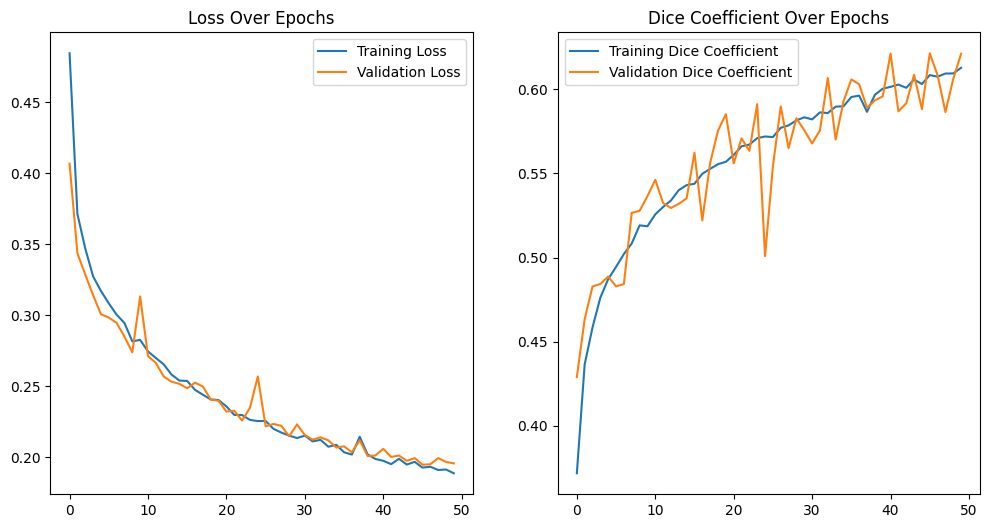

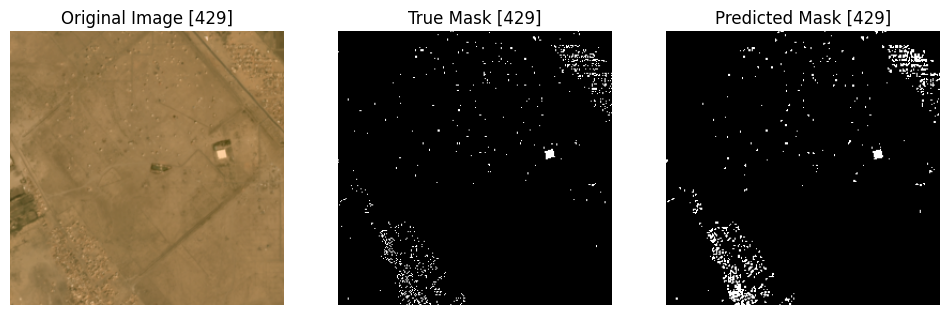

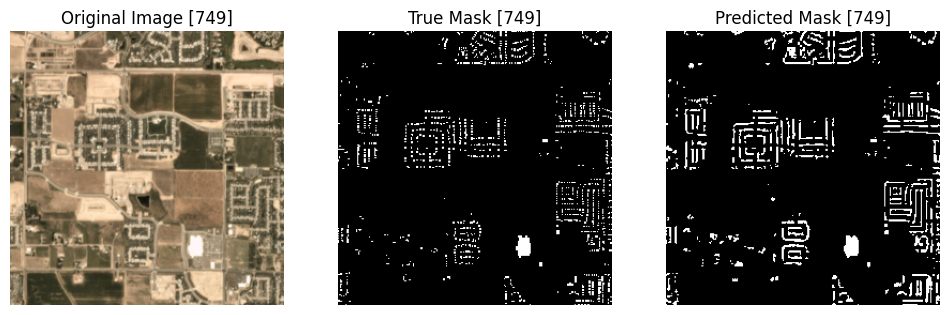

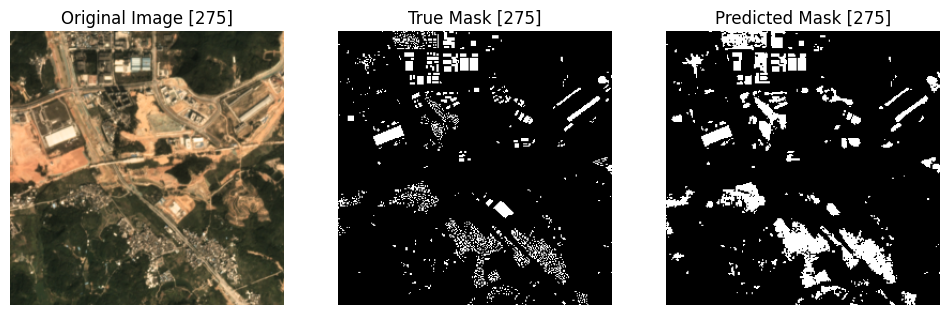

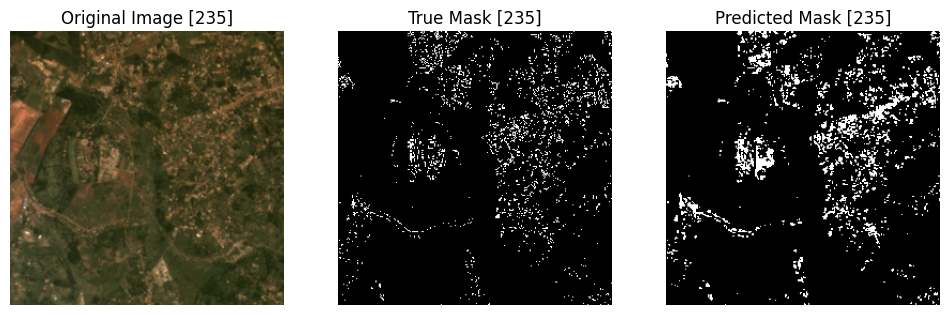

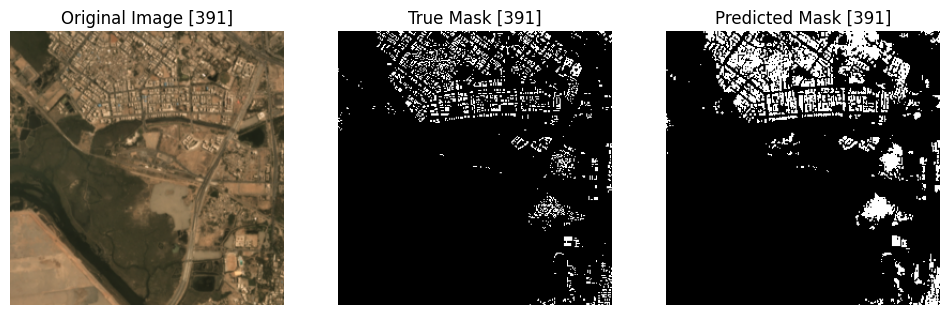

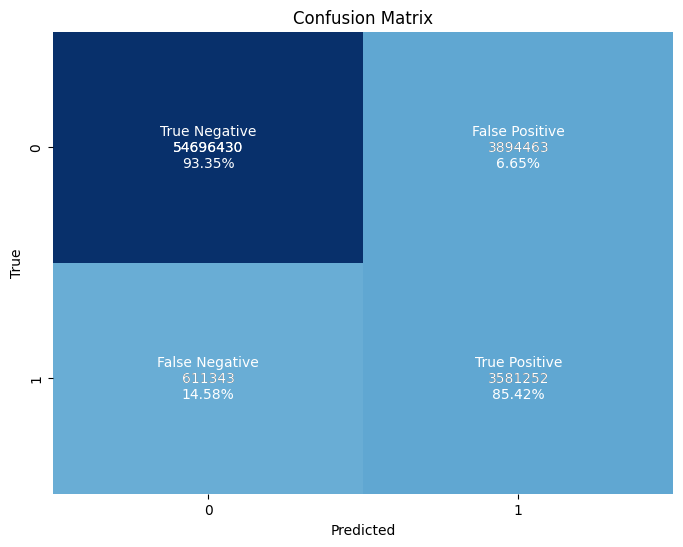

              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96  58590893
         1.0       0.48      0.85      0.61   4192595

    accuracy                           0.93  62783488
   macro avg       0.73      0.89      0.79  62783488
weighted avg       0.95      0.93      0.94  62783488

ROC-AUC: 0.9700245226590516


In [9]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns

# Evaluation functions

# Plot Training History
def plot_training_history(history):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['dice_coefficient'], label='Training Dice Coefficient')
    plt.plot(history.history['val_dice_coefficient'], label='Validation Dice Coefficient')
    plt.title('Dice Coefficient Over Epochs')
    plt.legend()

    plt.show()

# Show Predictions
def show_predictions(X, y_true, y_pred, threshold=threshold, num_samples=5):
    indices = np.random.choice(range(len(X)), num_samples, replace=False)

    for i in indices:
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 3, 1)
        plt.imshow(X[i])
        plt.title(f'Original Image [{i}]')
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(y_true[i].squeeze(), cmap='gray')
        plt.title(f'True Mask [{i}]')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(y_pred[i].squeeze() > threshold, cmap='gray')
        plt.title(f'Predicted Mask [{i}]')
        plt.axis('off')

        plt.show()

# Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, threshold=threshold):
    y_true_f = y_true.flatten()
    y_pred_f = (y_pred.flatten() > threshold).astype(int)  # Thresholding probabilities

    cm = confusion_matrix(y_true_f, y_pred_f)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize the confusion matrix

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')

    labels = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
    counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    percentages = ["{0:.2%}".format(value) for value in cm_normalized.flatten()]

    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(labels, counts, percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, center=0)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Perform the evaluation
y_pred = model.predict(X_test)

# Plot the training history
plot_training_history(history)

# Show sample predictions
show_predictions(X_test, y_test, y_pred, threshold=threshold)

# Plot confusion matrix
plot_confusion_matrix(y_test, y_pred, threshold=threshold)

# Print classification report
print(classification_report(y_test.flatten(), (y_pred.flatten() > threshold).astype(int)))

# Calculate and print ROC-AUC score
print("ROC-AUC:", roc_auc_score(y_test.flatten(), y_pred.flatten()))